# CIFAR-10 Image Super-Resolution with a Residual SRCNN

## Project overview

Image super-resolution reconstructs a higher-quality image from a low-resolution input.

This project creates synthetic low-resolution images by reducing CIFAR-10 images from 32×32 to 8×8 pixels. Bicubic interpolation expands them back to 32×32, after which a convolutional neural network learns to restore lost details.

The project compares:

1. Bicubic interpolation baseline
2. Residual Super-Resolution CNN

## Main questions

- Does the neural network improve PSNR, SSIM, and MAE over bicubic interpolation?
- Is the improvement consistent across images?
- Which semantic image classes are easiest or hardest to reconstruct?
- What types of images improve or deteriorate?
- Does the model restore meaningful details or only smooth pixel errors?

CIFAR-10 class labels are not used during training. They are retained only for post-hoc error analysis.

In [3]:
import copy
import hashlib
import pickle
import random
import tarfile
import time
import urllib.request
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset
from skimage.metrics import structural_similarity

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


## 1. Load CIFAR-10

CIFAR-10 contains small colour images from ten classes. The original images are 32×32 pixels.

A subset is used to keep training practical:

- 15,000 training images
- 3,000 validation images
- 2,000 test images

Training images receive random cropping and horizontal flipping. Validation and test images remain unchanged.

In [ ]:
DATA_DIRECTORY = Path("./data")
ARCHIVE_PATH = DATA_DIRECTORY / "cifar-10-python.tar.gz"
DATA_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
EXPECTED_MD5 = "c58f30108f718f92721af3b95e74349a"

DATA_DIRECTORY.mkdir(exist_ok=True)

def calculate_md5(path):
    digest = hashlib.md5()

    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()

if not ARCHIVE_PATH.exists() or calculate_md5(ARCHIVE_PATH) != EXPECTED_MD5:
    print("Downloading CIFAR-10...")
    urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)

Dataset archive ready.


In [5]:
def load_cifar_archive(archive_path):
    with tarfile.open(archive_path, "r:gz") as archive:
        def load_batch(filename):
            path = f"cifar-10-batches-py/{filename}"
            with archive.extractfile(path) as file:
                return pickle.load(file, encoding="bytes")

        train_batches = [
            load_batch(f"data_batch_{number}")
            for number in range(1, 6)
        ]

        test_batch = load_batch("test_batch")
        metadata = load_batch("batches.meta")

    train_images = np.concatenate([
        batch[b"data"] for batch in train_batches
    ]).reshape(-1, 3, 32, 32)

    train_labels = np.concatenate([
        np.asarray(batch[b"labels"]) for batch in train_batches
    ])

    test_images = test_batch[b"data"].reshape(-1, 3, 32, 32)
    test_labels = np.asarray(test_batch[b"labels"])
    class_names = [name.decode("utf-8") for name in metadata[b"label_names"]]

    return train_images, train_labels, test_images, test_labels, class_names

train_images, train_labels, test_images, test_labels, class_names = (
    load_cifar_archive(ARCHIVE_PATH)
)

print("Complete training data:", train_images.shape)
print("Complete test data:", test_images.shape)
print("Classes:", class_names)

Complete training data: (50000, 3, 32, 32)
Complete test data: (10000, 3, 32, 32)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
class CIFARTensorDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = torch.from_numpy(self.images[index].copy()).float() / 255
        label = int(self.labels[index])

        if self.augment:
            image = F.pad(image, (4, 4, 4, 4), mode="reflect")
            top = int(torch.randint(0, 9, (1,)).item())
            left = int(torch.randint(0, 9, (1,)).item())
            image = image[:, top:top + 32, left:left + 32]

            if torch.rand(1).item() < 0.5:
                image = torch.flip(image, dims=[2])

        return image, label

In [7]:
train_source = CIFARTensorDataset(train_images, train_labels, augment=True)
eval_source = CIFARTensorDataset(train_images, train_labels, augment=False)
test_source = CIFARTensorDataset(test_images, test_labels, augment=False)

rng = np.random.default_rng(SEED)
train_indices = rng.permutation(len(train_source))
test_indices = rng.permutation(len(test_source))

train_set = Subset(train_source, train_indices[:15000])
val_set = Subset(eval_source, train_indices[15000:18000])
test_set = Subset(test_source, test_indices[:2000])

print("Training:", len(train_set))
print("Validation:", len(val_set))
print("Test:", len(test_set))

Training: 15000
Validation: 3000
Test: 2000


In [8]:
BATCH_SIZE = 128

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=DEVICE.type == "cuda")

val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=DEVICE.type == "cuda")

test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=DEVICE.type == "cuda")

In [9]:
LOW_SIZE = 8
HIGH_SIZE = 32

def resize_bicubic(images, size):
    try:
        output = F.interpolate(
            images, size=(size, size), mode="bicubic",
            align_corners=False, antialias=True
        )
    except TypeError:
        output = F.interpolate(
            images, size=(size, size), mode="bicubic",
            align_corners=False
        )

    return output.clamp(0, 1)

def create_super_resolution_input(target):
    low_resolution = resize_bicubic(target, LOW_SIZE)
    bicubic_input = resize_bicubic(low_resolution, HIGH_SIZE)
    return low_resolution, bicubic_input

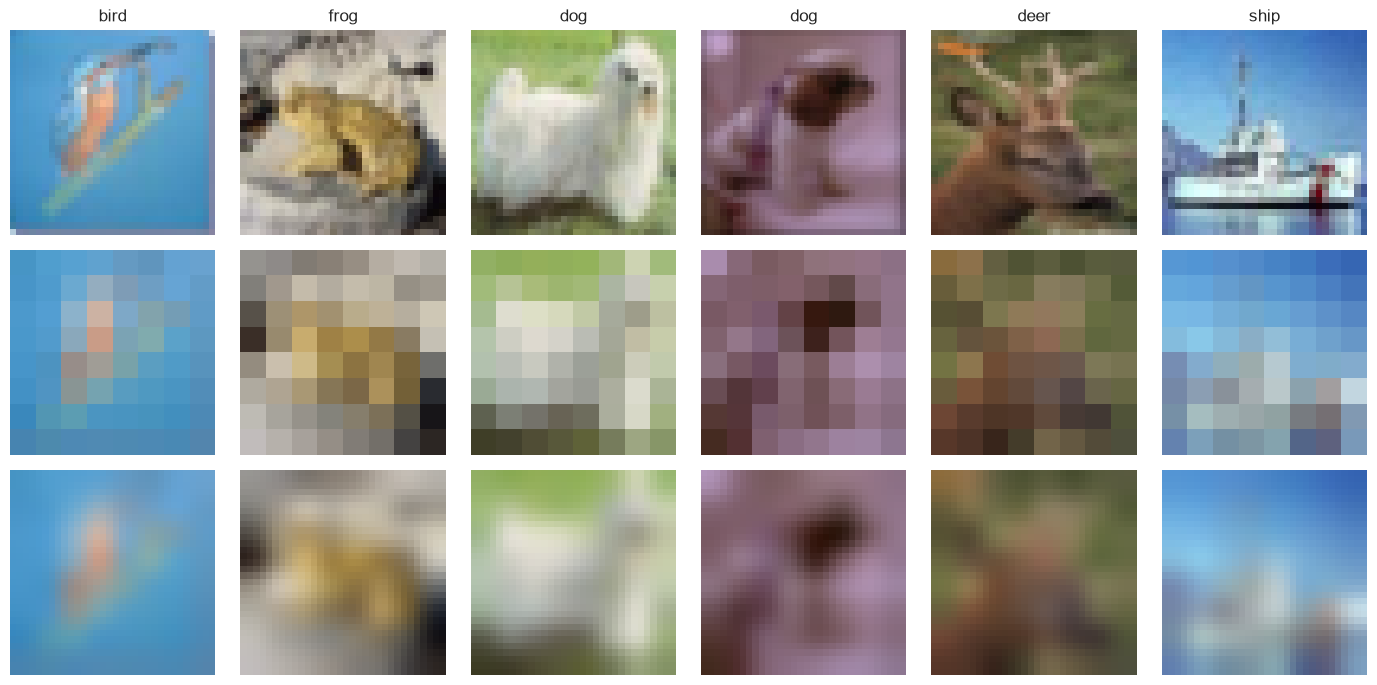

In [10]:
example_images, example_labels = next(iter(test_loader))
low_images, bicubic_images = create_super_resolution_input(example_images[:6])

fig, axes = plt.subplots(3, 6, figsize=(14, 7))

for i in range(6):
    axes[0, i].imshow(example_images[i].permute(1, 2, 0))
    axes[1, i].imshow(low_images[i].permute(1, 2, 0))
    axes[2, i].imshow(bicubic_images[i].permute(1, 2, 0))

    axes[0, i].set_title(class_names[example_labels[i]])
    axes[0, i].axis("off")
    axes[1, i].axis("off")
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("8×8 input")
axes[2, 0].set_ylabel("Bicubic")

plt.tight_layout()
plt.show()

### Initial image observations

Reducing the images from 32×32 to 8×8 removes most fine-grained information. Small textures, animal facial features, thin lines, object boundaries, and details such as antlers or ship structures are compressed into only a few colour blocks.

Bicubic interpolation removes the visible block boundaries and creates smoother 32×32 images. However, it cannot recover information lost during downsampling, so the resulting images remain strongly blurred.

Large colour regions and general object silhouettes remain visible. Images with clear foreground–background separation, such as ships against blue water or sky, retain more useful structure. Animals with fur, irregular outlines, complex backgrounds, or thin features appear more difficult to reconstruct.

This demonstrates the main challenge of four-times super-resolution: several different high-resolution images could correspond to the same 8×8 input, so perfect reconstruction is impossible.

## 2. Residual SRCNN

The network receives the bicubic-upscaled image and predicts a residual correction.

Starting from the bicubic image makes learning easier because the network only needs to estimate missing detail rather than recreate the complete image.

The output layer is initialised with zeros, so the untrained model initially behaves like the bicubic baseline.

In [11]:
class ResidualSRCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=9, padding=4),
            nn.PReLU(64),
            nn.Conv2d(64, 32, kernel_size=5, padding=2),
            nn.PReLU(32),
            nn.Conv2d(32, 3, kernel_size=5, padding=2)
        )

        nn.init.kaiming_normal_(self.network[0].weight)
        nn.init.kaiming_normal_(self.network[2].weight)
        nn.init.zeros_(self.network[-1].weight)
        nn.init.zeros_(self.network[-1].bias)

    def forward(self, bicubic_image):
        return bicubic_image + self.network(bicubic_image)

model = ResidualSRCNN().to(DEVICE)

parameter_count = sum(p.numel() for p in model.parameters())
print(model)
print(f"Trainable parameters: {parameter_count:,}")

ResidualSRCNN(
  (network): Sequential(
    (0): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (1): PReLU(num_parameters=64)
    (2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (3): PReLU(num_parameters=32)
    (4): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
)
Trainable parameters: 69,347


## 3. Training objective

The loss combines:

- pixel-level L1 loss;
- horizontal-gradient loss;
- vertical-gradient loss.

L1 loss encourages correct colour and brightness. Gradient loss places additional emphasis on edges and boundaries.

In [12]:
def gradient_loss(prediction, target):
    pred_dx = prediction[:, :, :, 1:] - prediction[:, :, :, :-1]
    target_dx = target[:, :, :, 1:] - target[:, :, :, :-1]

    pred_dy = prediction[:, :, 1:, :] - prediction[:, :, :-1, :]
    target_dy = target[:, :, 1:, :] - target[:, :, :-1, :]

    return F.l1_loss(pred_dx, target_dx) + F.l1_loss(pred_dy, target_dy)

def reconstruction_loss(prediction, target):
    pixel_loss = F.l1_loss(prediction, target)
    edge_loss = gradient_loss(prediction, target)
    return pixel_loss + 0.10 * edge_loss

In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)

def run_epoch(loader, training):
    model.train(training)
    total_loss = 0

    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for targets, _ in loader:
            targets = targets.to(DEVICE)
            _, inputs = create_super_resolution_input(targets)
            predictions = model(inputs)
            loss = reconstruction_loss(predictions, targets)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(targets)

    return total_loss / len(loader.dataset)

In [14]:
MAX_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3

history = []
best_state = None
best_val_loss = np.inf
epochs_without_improvement = 0
training_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(train_loader, training=True)
    val_loss = run_epoch(val_loader, training=False)
    scheduler.step(val_loss)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": val_loss,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })

    print(
        f"Epoch {epoch:02d} | train: {train_loss:.5f} | "
        f"validation: {val_loss:.5f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping activated.")
        break

model.load_state_dict(best_state)
training_seconds = time.time() - training_start

print(f"Best validation loss: {best_val_loss:.5f}")
print(f"Training time: {training_seconds:.1f} seconds")

Epoch 01 | train: 0.07553 | validation: 0.07317
Epoch 02 | train: 0.07248 | validation: 0.07225
Epoch 03 | train: 0.07170 | validation: 0.07134
Epoch 04 | train: 0.07087 | validation: 0.07096
Epoch 05 | train: 0.07057 | validation: 0.07042
Epoch 06 | train: 0.07028 | validation: 0.07029
Epoch 07 | train: 0.07000 | validation: 0.07021
Epoch 08 | train: 0.06992 | validation: 0.06991
Epoch 09 | train: 0.06974 | validation: 0.06969
Epoch 10 | train: 0.06967 | validation: 0.06983
Best validation loss: 0.06969
Training time: 634.1 seconds


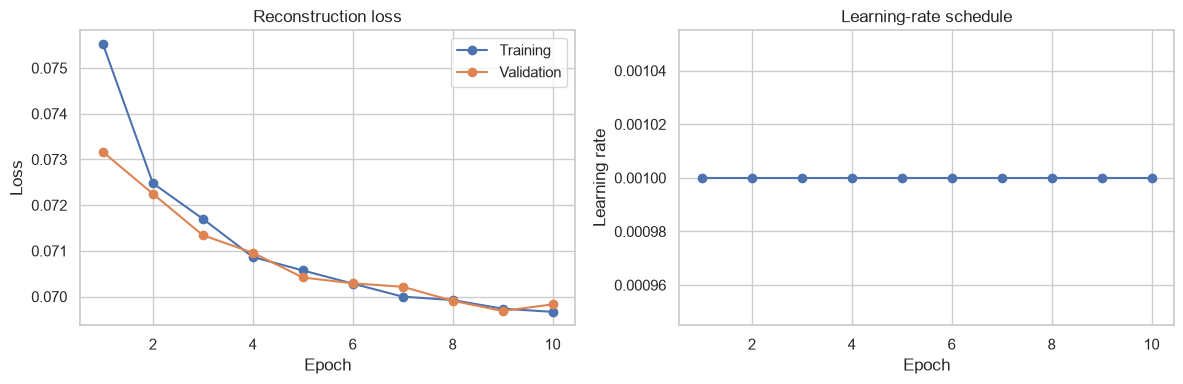

In [15]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training")
axes[0].plot(history_df["epoch"], history_df["validation_loss"], marker="o", label="Validation")
axes[0].set(title="Reconstruction loss", xlabel="Epoch", ylabel="Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["learning_rate"], marker="o")
axes[1].set(title="Learning-rate schedule", xlabel="Epoch", ylabel="Learning rate")

plt.tight_layout()
plt.show()

### Training findings

The Residual SRCNN contains **69,347 trainable parameters** and was trained for all ten scheduled epochs on the CPU.

Training loss decreased from **0.07553 to 0.06967**, while validation loss decreased from **0.07317 to a best value of 0.06969 at epoch 9**. Validation loss increased slightly to 0.06983 during epoch 10, so the epoch-9 weights were restored.

Training and validation losses remain very close throughout training. Validation loss is occasionally lower because data augmentation makes the training images slightly more difficult. There is no substantial evidence of overfitting, although the small increase during the final epoch suggests that improvement was beginning to plateau.

The learning rate remained at 0.001 because validation loss continued to improve frequently enough that the scheduler was not activated. Early stopping was also not triggered because the maximum epoch count was reached first.

Training required approximately **634 seconds, or 10.6 minutes**, on the CPU. Further training may produce small improvements, but the flattening curves suggest diminishing returns with the current architecture.

## 4. Test-set reconstruction

Three images are retained for each test observation:

- original high-resolution target;
- bicubic interpolation;
- neural-network reconstruction.

In [16]:
@torch.no_grad()
def collect_test_outputs(loader):
    model.eval()
    targets, bicubic_outputs, model_outputs, labels = [], [], [], []

    for target_batch, label_batch in loader:
        target_batch = target_batch.to(DEVICE)
        _, bicubic_batch = create_super_resolution_input(target_batch)
        prediction_batch = model(bicubic_batch).clamp(0, 1)

        targets.append(target_batch.cpu())
        bicubic_outputs.append(bicubic_batch.cpu())
        model_outputs.append(prediction_batch.cpu())
        labels.append(label_batch)

    return (
        torch.cat(targets),
        torch.cat(bicubic_outputs),
        torch.cat(model_outputs),
        torch.cat(labels)
    )

test_targets, test_bicubic, test_predictions, test_labels = collect_test_outputs(test_loader)

print("Output shape:", test_predictions.shape)

Output shape: torch.Size([2000, 3, 32, 32])


## 5. Quantitative evaluation

The evaluation uses:

- **MAE:** average absolute pixel error; lower is better.
- **PSNR:** reconstruction quality based on mean squared error; higher is better.
- **SSIM:** similarity of structural patterns, contrast, and luminance; higher is better.

Bicubic and model predictions are evaluated on exactly the same test images.

In [17]:
def calculate_ssim(reference, candidate):
    reference = reference.permute(1, 2, 0).numpy()
    candidate = candidate.permute(1, 2, 0).numpy()

    try:
        return structural_similarity(
            reference, candidate, channel_axis=-1, data_range=1
        )
    except TypeError:
        return structural_similarity(
            reference, candidate, multichannel=True, data_range=1
        )

def calculate_metrics(reference, candidate):
    errors = candidate - reference
    mse = errors.square().mean(dim=(1, 2, 3)).numpy()
    mae = errors.abs().mean(dim=(1, 2, 3)).numpy()
    psnr = 10 * np.log10(1 / np.clip(mse, 1e-12, None))

    ssim = np.array([
        calculate_ssim(reference[i], candidate[i])
        for i in range(len(reference))
    ])

    return pd.DataFrame({"mae": mae, "psnr": psnr, "ssim": ssim})

bicubic_metrics = calculate_metrics(test_targets, test_bicubic)
model_metrics = calculate_metrics(test_targets, test_predictions)

In [18]:
metric_summary = pd.DataFrame([
    {
        "method": "Bicubic",
        "mae": bicubic_metrics["mae"].mean(),
        "psnr": bicubic_metrics["psnr"].mean(),
        "ssim": bicubic_metrics["ssim"].mean()
    },
    {
        "method": "Residual SRCNN",
        "mae": model_metrics["mae"].mean(),
        "psnr": model_metrics["psnr"].mean(),
        "ssim": model_metrics["ssim"].mean()
    }
])

metric_summary.round(4)

,method,mae,psnr,ssim
0,Bicubic,0.0662,21.013300,0.6284
1,Residual SRCNN,0.0599,21.762899,0.6935


In [19]:
improvement_df = pd.DataFrame({
    "mae_reduction": bicubic_metrics["mae"] - model_metrics["mae"],
    "psnr_gain": model_metrics["psnr"] - bicubic_metrics["psnr"],
    "ssim_gain": model_metrics["ssim"] - bicubic_metrics["ssim"]
})

improvement_summary = pd.Series({
    "Mean PSNR gain": improvement_df["psnr_gain"].mean(),
    "Median PSNR gain": improvement_df["psnr_gain"].median(),
    "Images with higher PSNR (%)": 100 * (improvement_df["psnr_gain"] > 0).mean(),
    "Mean SSIM gain": improvement_df["ssim_gain"].mean(),
    "Images with higher SSIM (%)": 100 * (improvement_df["ssim_gain"] > 0).mean(),
    "Mean MAE reduction": improvement_df["mae_reduction"].mean()
}, name="value").to_frame()

improvement_summary.round(4)

,value
Mean PSNR gain,0.7496
Median PSNR gain,0.6710
Images with higher PSNR (%),99.5500
Mean SSIM gain,0.0651
Images with higher SSIM (%),99.7500
Mean MAE reduction,0.0063


In [20]:
bootstrap_rng = np.random.default_rng(SEED)
psnr_difference = improvement_df["psnr_gain"].to_numpy()

bootstrap_means = np.array([
    bootstrap_rng.choice(psnr_difference, size=len(psnr_difference), replace=True).mean()
    for _ in range(3000)
])

confidence_interval = np.percentile(bootstrap_means, [2.5, 97.5])

print(f"Mean PSNR improvement: {psnr_difference.mean():.4f} dB")
print(
    "95% paired bootstrap CI: "
    f"[{confidence_interval[0]:.4f}, {confidence_interval[1]:.4f}] dB"
)

Mean PSNR improvement: 0.7496 dB
95% paired bootstrap CI: [0.7314, 0.7680] dB


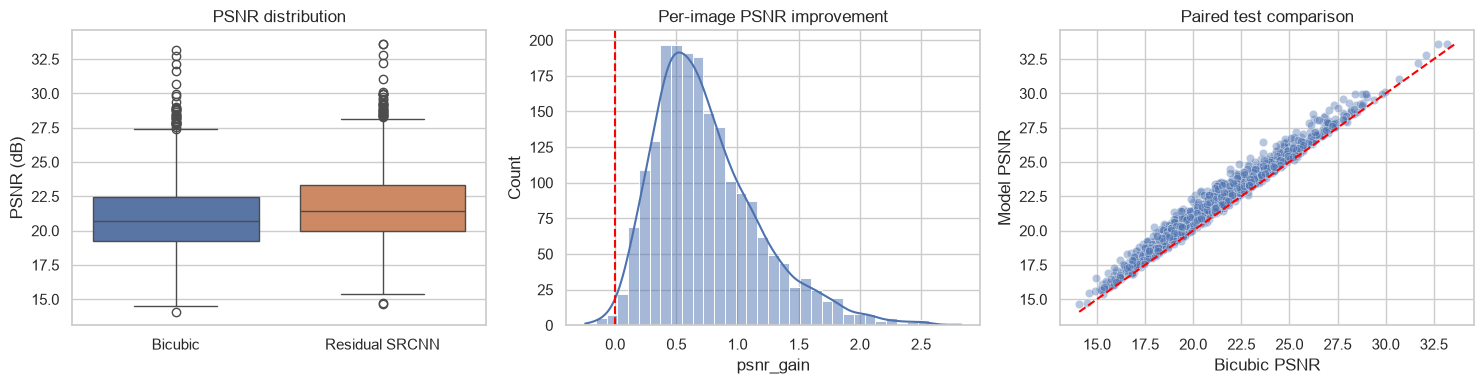

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=pd.DataFrame({
    "Bicubic": bicubic_metrics["psnr"],
    "Residual SRCNN": model_metrics["psnr"]
}), ax=axes[0])
axes[0].set_title("PSNR distribution")
axes[0].set_ylabel("PSNR (dB)")

sns.histplot(improvement_df["psnr_gain"], bins=35, kde=True, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Per-image PSNR improvement")

sns.scatterplot(
    x=bicubic_metrics["psnr"],
    y=model_metrics["psnr"],
    alpha=0.4,
    ax=axes[2]
)
limits = [
    min(bicubic_metrics["psnr"].min(), model_metrics["psnr"].min()),
    max(bicubic_metrics["psnr"].max(), model_metrics["psnr"].max())
]
axes[2].plot(limits, limits, "--", color="red")
axes[2].set(title="Paired test comparison", xlabel="Bicubic PSNR", ylabel="Model PSNR")

plt.tight_layout()
plt.show()

### Quantitative evaluation 

The Residual SRCNN improves all three reconstruction metrics over bicubic interpolation.

| Method | MAE ↓ | PSNR ↑ | SSIM ↑ |
|---|---:|---:|---:|
| Bicubic | 0.0662 | 21.0133 dB | 0.6284 |
| Residual SRCNN | 0.0599 | 21.7629 dB | 0.6935 |

The network reduces mean absolute error by **0.0063**, which is approximately a 9.5% reduction from the bicubic baseline. Mean PSNR increases by **0.7496 dB**, while SSIM increases by **0.0651**.

The median PSNR gain is 0.6710 dB, slightly below the mean because a smaller number of images achieve particularly large improvements. The model improves PSNR for **99.55% of test images** and SSIM for **99.75%**, demonstrating that the result is highly consistent rather than being driven by a few successful examples.

The paired bootstrap 95% confidence interval for mean PSNR improvement is **[0.7314, 0.7680] dB**. Since the complete interval is above zero and relatively narrow, the average improvement is strongly supported across this test sample.

The improvement is meaningful but not transformative. The network produces consistently better pixel and structural similarity, but it cannot recreate all details lost when compressing an image to only 8×8 pixels.

## 6. Class-level error analysis

CIFAR-10 labels were not used to train the reconstruction model. They are now used to determine whether certain visual categories are easier or harder to reconstruct.

In [22]:
class_analysis_df = pd.DataFrame({
    "class": [class_names[label] for label in test_labels.numpy()],
    "bicubic_psnr": bicubic_metrics["psnr"],
    "model_psnr": model_metrics["psnr"],
    "psnr_gain": improvement_df["psnr_gain"],
    "model_ssim": model_metrics["ssim"]
})

class_results = class_analysis_df.groupby("class").agg(
    observations=("class", "size"),
    bicubic_psnr=("bicubic_psnr", "mean"),
    model_psnr=("model_psnr", "mean"),
    psnr_gain=("psnr_gain", "mean"),
    model_ssim=("model_ssim", "mean")
).sort_values("model_psnr", ascending=False)

class_results.round(4)

,observations,bicubic_psnr,model_psnr,psnr_gain,model_ssim
class,,,,,
deer,205,22.713499,23.316900,0.6033,0.6777
bird,177,21.952999,22.770201,0.8172,0.7141
airplane,210,21.816900,22.637501,0.8206,0.7164
ship,197,21.357201,22.157101,0.7999,0.7025
dog,217,21.069500,21.975500,0.9060,0.7322
cat,217,21.157101,21.940500,0.7834,0.7159
frog,211,21.228201,21.825399,0.5971,0.6404
horse,185,20.029600,20.799900,0.7703,0.6837
truck,198,19.382299,20.110901,0.7286,0.6684


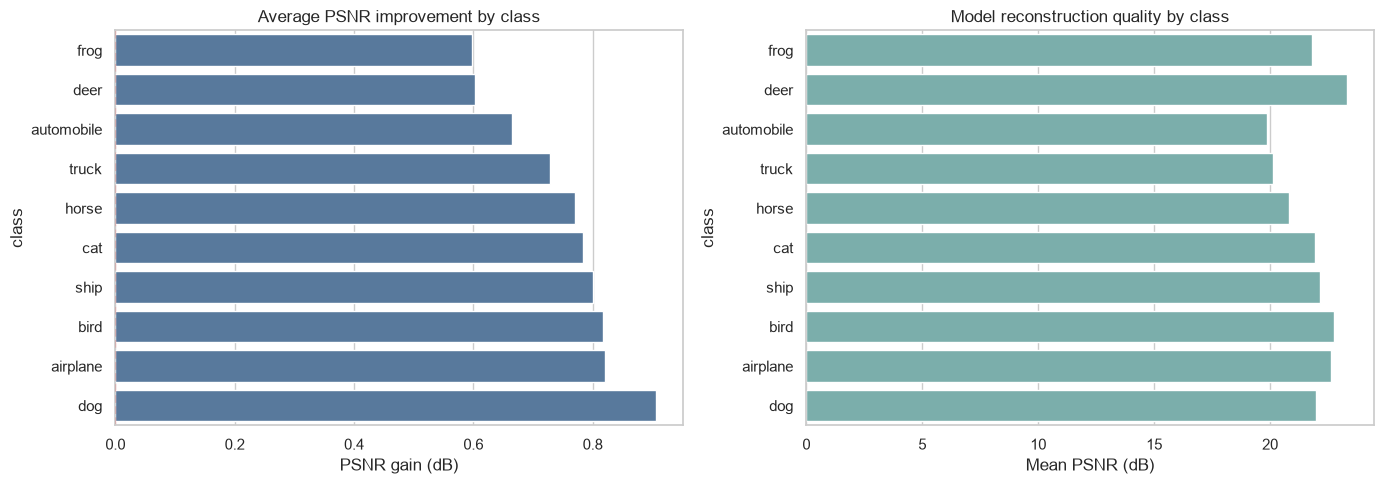

In [23]:
plot_df = class_results.reset_index().sort_values("psnr_gain")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=plot_df, x="psnr_gain", y="class", color="#4c78a8", ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Average PSNR improvement by class")
axes[0].set_xlabel("PSNR gain (dB)")

sns.barplot(data=plot_df, x="model_psnr", y="class", color="#72b7b2", ax=axes[1])
axes[1].set_title("Model reconstruction quality by class")
axes[1].set_xlabel("Mean PSNR (dB)")

plt.tight_layout()
plt.show()

### Class-level findings

The highest absolute model PSNR occurs for:

- deer: **23.32 dB**;
- bird: **22.77 dB**;
- airplane: **22.64 dB**;
- ship: **22.16 dB**.

The lowest reconstruction quality occurs for automobiles at 19.85 dB, trucks at 20.11 dB, and horses at 20.80 dB.

Absolute PSNR does not necessarily indicate semantic recognisability. It is also influenced by image contrast, texture, colour variation, and the proportion of smooth background pixels. Natural images with smoother colour regions can achieve high PSNR even when small object details remain unclear.

The greatest average improvement over bicubic interpolation occurs for dogs at **0.9060 dB**, followed by airplanes at 0.8206 dB, birds at 0.8172 dB, and ships at 0.7999 dB.

Frogs and deer show the smallest average gains at approximately 0.60 dB. Deer already have the strongest bicubic baseline, leaving less room for improvement. Dogs have only moderate absolute PSNR but achieve the largest improvement and highest average model SSIM of 0.7322.

Vehicles may be difficult because their appearance depends on sharp edges, windows, wheels, and structured boundaries that are easily destroyed during 8×8 downsampling. Animal classes also contain substantial variation in pose, texture, and background, producing different reconstruction difficulties within the same class.

## 7. Visual reconstruction analysis

Quantitative metrics do not reveal whether the restored details look natural. Original targets, bicubic baselines, neural reconstructions, and absolute error maps are compared visually.

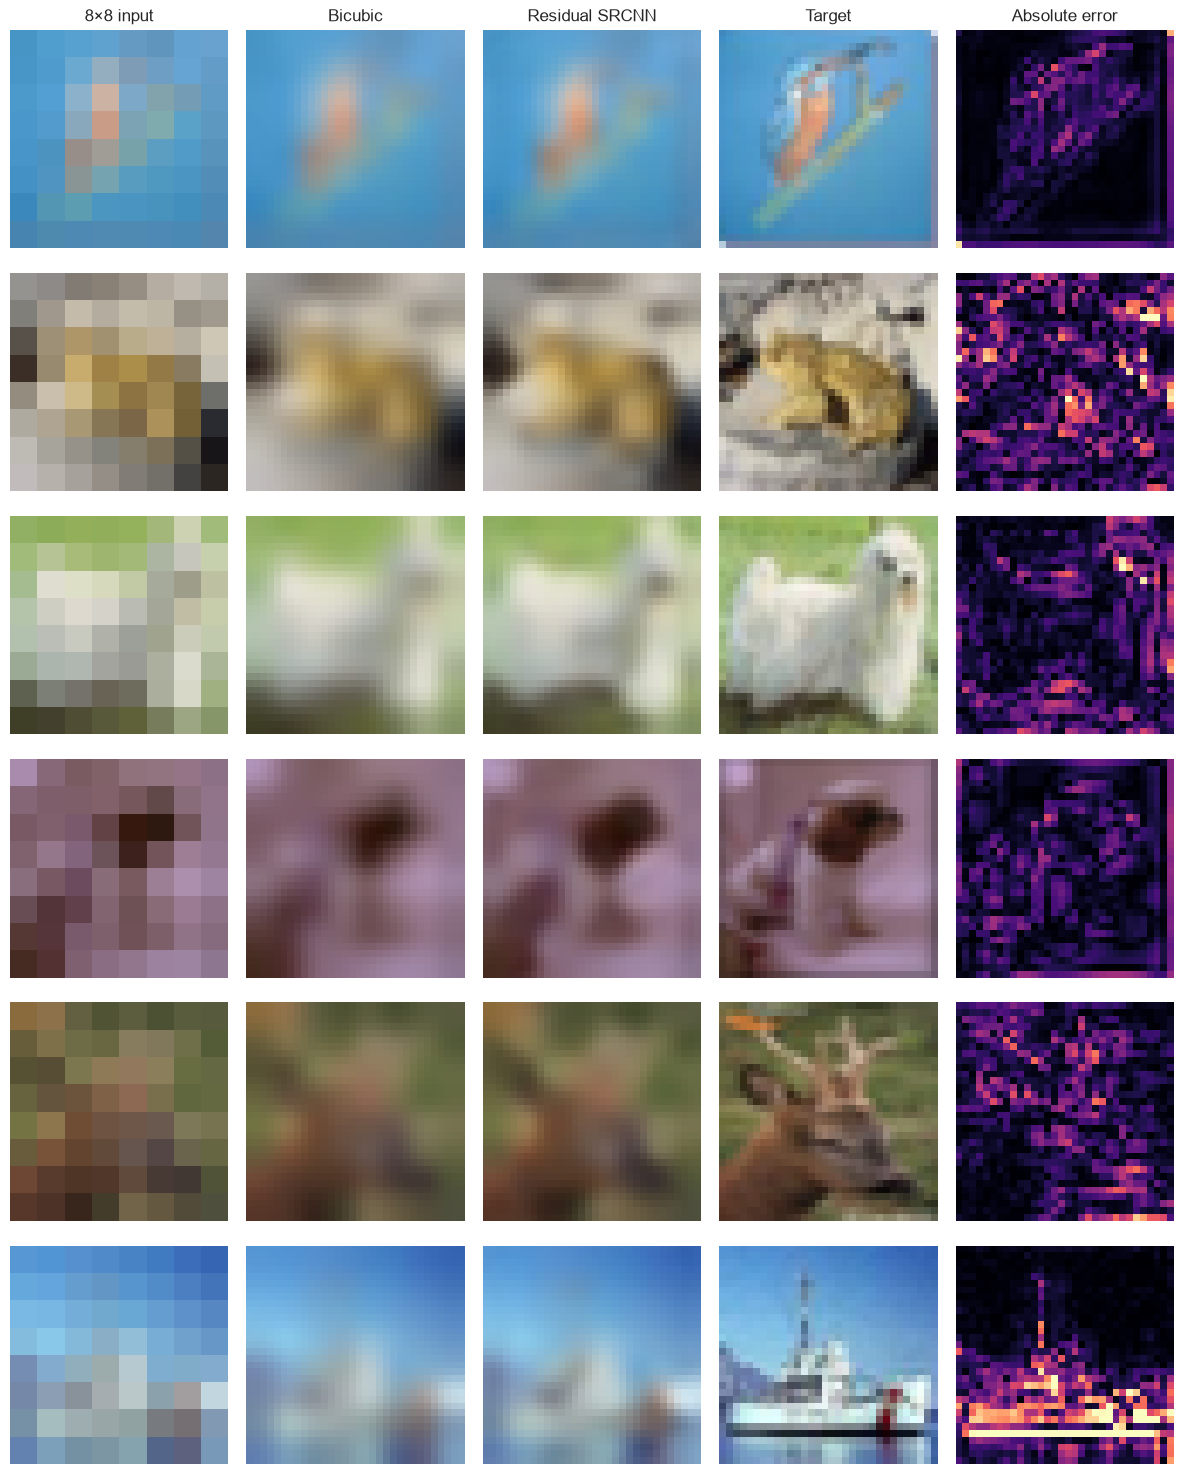

In [24]:
display_indices = np.arange(6)
low_display = resize_bicubic(test_targets[display_indices], LOW_SIZE)

fig, axes = plt.subplots(len(display_indices), 5, figsize=(12, 15))

for row, index in enumerate(display_indices):
    target = test_targets[index].permute(1, 2, 0)
    bicubic = test_bicubic[index].permute(1, 2, 0)
    prediction = test_predictions[index].permute(1, 2, 0)
    error = (test_predictions[index] - test_targets[index]).abs().mean(0)

    axes[row, 0].imshow(low_display[row].permute(1, 2, 0))
    axes[row, 1].imshow(bicubic)
    axes[row, 2].imshow(prediction)
    axes[row, 3].imshow(target)
    axes[row, 4].imshow(error, cmap="magma", vmin=0, vmax=0.3)

    axes[row, 0].set_ylabel(class_names[test_labels[index]])
    for ax in axes[row]:
        ax.axis("off")

titles = ["8×8 input", "Bicubic", "Residual SRCNN", "Target", "Absolute error"]
for column, title in enumerate(titles):
    axes[0, column].set_title(title)

plt.tight_layout()
plt.show()

In [25]:
best_indices = improvement_df["psnr_gain"].nlargest(3).index.to_numpy()
worst_indices = improvement_df["psnr_gain"].nsmallest(3).index.to_numpy()
selected_indices = np.concatenate([best_indices, worst_indices])

comparison_rows = []

for index in selected_indices:
    comparison_rows.append({
        "test_index": index,
        "class": class_names[test_labels[index]],
        "bicubic_psnr": bicubic_metrics.loc[index, "psnr"],
        "model_psnr": model_metrics.loc[index, "psnr"],
        "psnr_gain": improvement_df.loc[index, "psnr_gain"],
        "model_ssim": model_metrics.loc[index, "ssim"]
    })

pd.DataFrame(comparison_rows).round(4)

,test_index,class,bicubic_psnr,model_psnr,psnr_gain,model_ssim
0,884,ship,23.614799,26.443600,2.8288,0.8767
1,1000,dog,21.938999,24.476801,2.5377,0.8622
2,339,ship,20.108000,22.616600,2.5086,0.7945
3,404,dog,22.825701,22.580700,-0.2449,0.6944
4,262,airplane,19.348801,19.222300,-0.1265,0.4141
5,357,airplane,21.533800,21.409800,-0.1240,0.7294


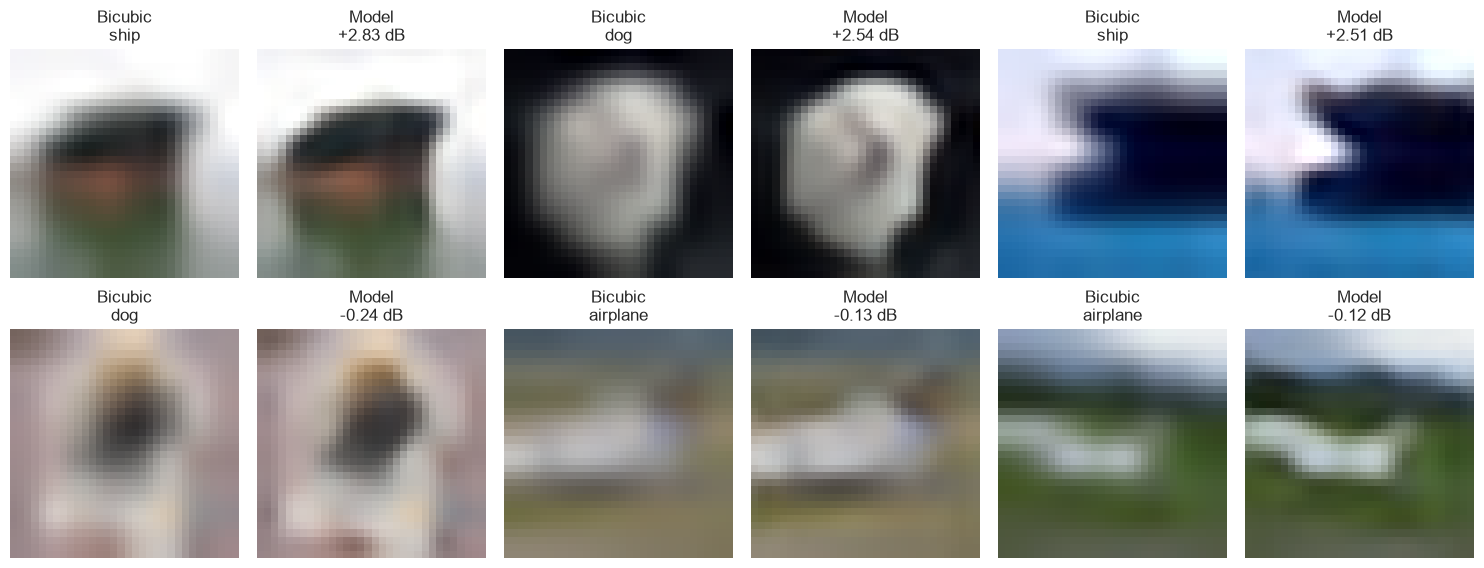

In [26]:
fig, axes = plt.subplots(2, 6, figsize=(15, 6))

for column, index in enumerate(best_indices):
    axes[0, column * 2].imshow(test_bicubic[index].permute(1, 2, 0))
    axes[0, column * 2 + 1].imshow(test_predictions[index].permute(1, 2, 0))
    axes[0, column * 2].set_title(f"Bicubic\n{class_names[test_labels[index]]}")
    axes[0, column * 2 + 1].set_title(f"Model\n+{improvement_df.loc[index, 'psnr_gain']:.2f} dB")

for column, index in enumerate(worst_indices):
    axes[1, column * 2].imshow(test_bicubic[index].permute(1, 2, 0))
    axes[1, column * 2 + 1].imshow(test_predictions[index].permute(1, 2, 0))
    axes[1, column * 2].set_title(f"Bicubic\n{class_names[test_labels[index]]}")
    axes[1, column * 2 + 1].set_title(f"Model\n{improvement_df.loc[index, 'psnr_gain']:.2f} dB")

for ax in axes.flat:
    ax.axis("off")

axes[0, 0].set_ylabel("Best gains")
axes[1, 0].set_ylabel("Worst gains")

plt.tight_layout()
plt.show()

### Visual error analysis 

The Residual SRCNN generally produces slightly sharper boundaries, stronger local contrast, and more defined colour transitions than bicubic interpolation. The improvement is most visible around large object silhouettes and high-contrast regions.

The absolute error maps show that most remaining errors occur around edges, textures, thin structures, and detailed backgrounds. These are precisely the high-frequency components removed during downsampling.

The strongest example is a ship image with a PSNR gain of **2.83 dB** and SSIM of 0.8767. Two other strong examples—a dog and another ship—improve by 2.54 dB and 2.51 dB. In these cases, the model produces cleaner foreground boundaries and reduces some of the broad bicubic blur.

Only a small number of images deteriorate. The largest decrease is −0.24 dB for a dog, followed by two airplane images at approximately −0.13 and −0.12 dB. These changes are relatively small but show that learned edge or colour corrections can occasionally move the prediction away from the true target.

The model does not recreate fine details such as fur, antlers, facial features, or narrow ship structures. It also does not show severe ringing or obviously invented objects; instead, its outputs remain fairly smooth. This behaviour is consistent with a shallow network trained mainly through pixel and gradient losses.